# 07221203_2025 dump 1 — why does `bstd_1000` have so many more high-`bstd` traces than `bstd`?

Series `07221203_2025`, dump `F0001`, **Detector 0 / Channel 0** (1517 traces). Follows
`07221203_2025_dump1_noise.ipynb`, where the 1000-sample baseline scatter had far more
high-`bstd` traces than the 500-sample one (for example 25% vs. 2% above `bstd = 32.48`).

Two ideas to test:

1. **Random pulses.** If pulses land at random positions in the 4096-sample trace, the chance of one
   in the pretrigger region should scale with the window length, 1000/4096 vs. 500/4096, only a factor
   of 2. (A pulse that starts earlier also has more time to raise the scatter, which would push the
   ratio above 2.)
2. **A change in the data.** At some point the dump could switch to triggered data whose trigger
   point sits somewhere between sample 500 and 1000.

Starting point: `bstd` and `bstd_1000` plotted against time. Events are numbered in time order
within a dump, so the event number is the time axis here. Uses the `python/` library
(`pulse_io`, `pulse_quantities.bstd` / `bstd_1000`). Run with the `darkmatter_cli_env` environment.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[1] / "python"))

from nsdf_dark_matter.idx import load_all_data

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import pulse_io as pio
import pulse_quantities as pq

cdms = load_all_data(str(Path.home()) + '/idx/07221203_2025_F0001')

DETECTOR, CHANNEL = 0, 0
detector_id_arr, pulses = pio.load_channel_batch(
    cdms, pio.filter_by_detector(cdms.get_detector_ids(), DETECTOR), CHANNEL)

event = np.array([int(i.split('_')[0]) for i in detector_id_arr])
trigger = np.array([cdms.get_event_metadata(str(e)).trigger_type for e in event])   # from the dump's .csv
bstd_500 = pq.bstd(pulses)          # first 500 samples (leading glitch samples skipped)
bstd_1000 = pq.bstd_1000(pulses)    # first 1000 samples

print(f"{len(event)} traces, events {event.min()}-{event.max()}, in time order: {bool(np.all(np.diff(event) > 0))}")
print("trigger types:", {t: int((trigger == t).sum()) for t in np.unique(trigger)})

1517 traces, events 10000-11569, in time order: True
trigger types: {np.str_('Physics'): 1008, np.str_('Unknown'): 509}


## `bstd` and `bstd_1000` against event number

Grey bands mark events whose recorded trigger type is `Unknown` (the rest are `Physics`). Dashed line:
`bstd = 32.48`, the cap used in `07221203_2025_dump1_noise.ipynb`.

first Unknown-trigger event: 11000; 8 runs of Unknown events, lengths [57, 63, 72, 76, 72, 62, 58, 49]


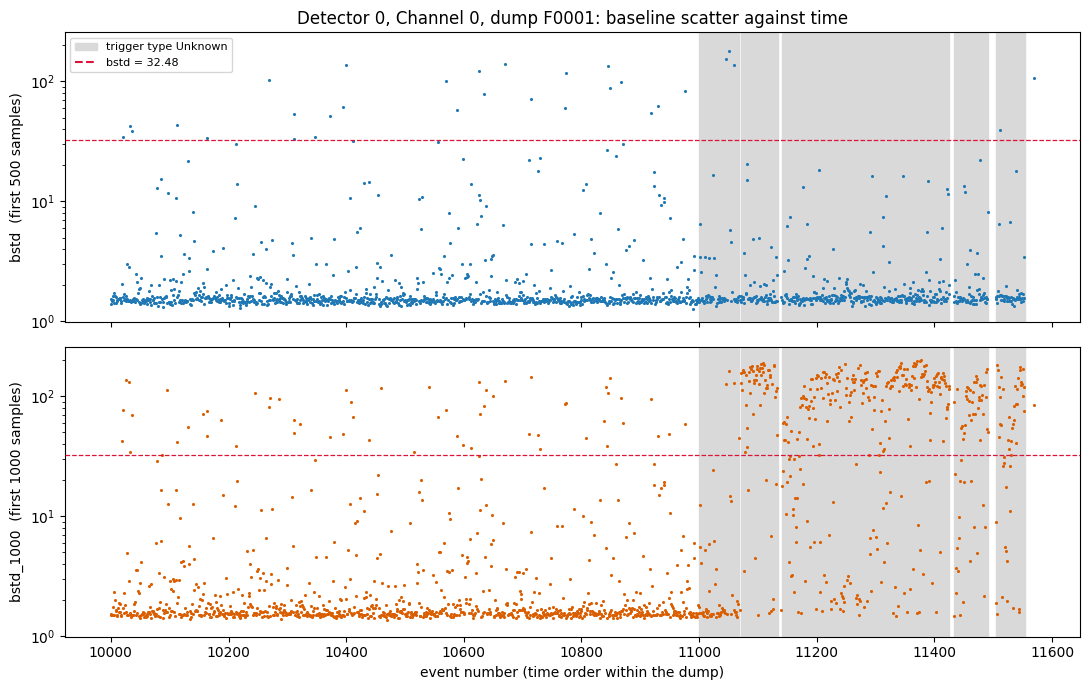

In [2]:
BSTD_CAP = 32.48

is_unknown = trigger == "Unknown"
first_unknown = int(event[is_unknown].min())
groups = np.split(np.arange(len(event)), np.flatnonzero(np.diff(is_unknown.astype(int))) + 1)
unknown_spans = [(event[g[0]], event[g[-1]]) for g in groups if is_unknown[g[0]]]
print(f"first Unknown-trigger event: {first_unknown}; {len(unknown_spans)} runs of Unknown events, "
      f"lengths {[len(g) for g in groups if is_unknown[g[0]]]}")

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, sharey=True)
for ax, y, label, color in ((axes[0], bstd_500, "bstd  (first 500 samples)", "#1f77b4"),
                            (axes[1], bstd_1000, "bstd_1000  (first 1000 samples)", "#d95f02")):
    for lo, hi in unknown_spans:
        ax.axvspan(lo - 0.5, hi + 0.5, color="0.85", zorder=0)
    ax.scatter(event, y, s=5, color=color, linewidths=0, zorder=2)
    ax.axhline(BSTD_CAP, color="crimson", linestyle="--", linewidth=0.9, zorder=3)
    ax.set_yscale("log")
    ax.set_ylabel(label)

axes[0].set_title("Detector 0, Channel 0, dump F0001: baseline scatter against time")
axes[1].set_xlabel("event number (time order within the dump)")
axes[0].legend(handles=[Patch(color="0.85", label="trigger type Unknown"),
                        Line2D([0], [0], color="crimson", linestyle="--", label=f"bstd = {BSTD_CAP}")],
               loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

## How the high-`bstd` fraction differs between the two parts of the dump

Naive expectation for randomly placed pulses: the fraction with a pulse in the window scales with the
window length, so `bstd_1000` should exceed `bstd` by a factor of about 2 (1000/500).

In [3]:
regions = {
    f"events before {first_unknown} (all Physics)": event < first_unknown,
    f"from {first_unknown} on, trigger Unknown": (event >= first_unknown) & is_unknown,
    f"from {first_unknown} on, trigger Physics": (event >= first_unknown) & ~is_unknown,
    "all traces": np.ones(len(event), dtype=bool),
}

print(f"{'region':<38}{'traces':>7}  {'median bstd':>11} {'median bstd_1000':>17}  "
      f"{'% bstd>cap':>10} {'% bstd_1000>cap':>16} {'ratio':>6}")
for name, m in regions.items():
    f500, f1000 = 100 * (bstd_500[m] > BSTD_CAP).mean(), 100 * (bstd_1000[m] > BSTD_CAP).mean()
    ratio = f1000 / f500 if f500 > 0 else float("inf")
    print(f"{name:<38}{m.sum():>7}  {np.median(bstd_500[m]):>11.2f} {np.median(bstd_1000[m]):>17.2f}  "
          f"{f500:>10.1f} {f1000:>16.1f} {ratio:>6.1f}")
print(f"\nnaive random-placement expectation for the ratio: {1000 / 500:.1f}")

region                                 traces  median bstd  median bstd_1000  % bstd>cap  % bstd_1000>cap  ratio
events before 11000 (all Physics)        1000         1.53              1.61         2.7              5.9    2.2
from 11000 on, trigger Unknown            509         1.56             78.20         0.8             62.7   79.8
from 11000 on, trigger Physics              8         1.86              2.57        12.5             12.5    1.0
all traces                               1517         1.54              1.88         2.1             25.0   11.8

naive random-placement expectation for the ratio: 2.0


In [4]:
above = bstd_1000 > BSTD_CAP
print(f"traces with bstd_1000 > {BSTD_CAP}: {above.sum()} of {len(event)}; where they come from:")
for name, m in list(regions.items())[:3]:
    print(f"  {name:<38}{(above & m).sum():>5}  ({100 * (above & m).sum() / above.sum():.0f}% of them)")

ts = np.array([cdms.get_event_metadata(str(e)).global_timestamp for e in event])
print(f"\nglobal timestamps in the .csv: {len(np.unique(ts))} distinct values, from {ts[0]}  to  {ts[-1]}")

traces with bstd_1000 > 32.48: 379 of 1517; where they come from:
  events before 11000 (all Physics)        59  (16% of them)
  from 11000 on, trigger Unknown          319  (84% of them)
  from 11000 on, trigger Physics            1  (0% of them)

global timestamps in the .csv: 57 distinct values, from Sunday, December 04, 2022 02:25:47 AM UTC  to  Sunday, December 04, 2022 02:26:45 AM UTC
